# Analyse X-MACE predictions

For the best plots, use a grid as `XYZ_FILE`. Run `run_predictions.py` on it before using this notebook. 

`XYZ_FILE` must contain `PRED_energy`; it may also contain `REF_energy` for residual plots.

All atom indices are 1-based.

In [1]:
# Imports and inputs

from pathlib import Path
import sys
import matplotlib.pyplot as plt
from ase.io import read

repository_path = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "analysis_tools" / "analyse_model" / "analyse_model.ipynb").is_file()
)
sys.path[:0] = [str(repository_path)]
from analysis_tools.analyse_data.geometry_coordinates import (
    BondAngleCoordinate,
    BondLengthCoordinate,
    DihedralCoordinate,
)
from analysis_tools.analyse_model.plot_predictions import plot_pred_energy_mesh
from analysis_tools.analyse_model.plot_residuals import (
    plot_residual_heatmaps,
    plot_residual_vs_coordinate,
    plot_residual_vs_gap,
)

XYZ_FILE = Path("/home/lim_yt/X-MACE-tools/analysis_tools/analyse_model/A01_ethene_grid_static_CASSCF_101_grid.xyz")
atoms_list = read(XYZ_FILE, index=":")

print(f'Number of geometries: {len(atoms_list)}')
try:
    atoms_list[0].info['PRED_energy']
except:
    print('File contains no PRED_energy, run run_predictions.py before using this notebook.')

Number of geometries: 101


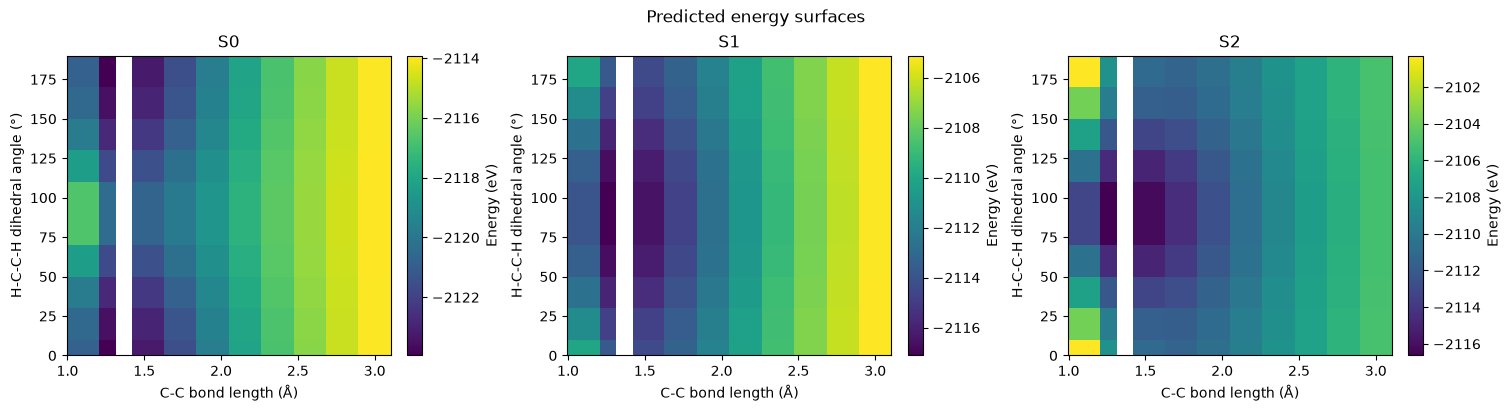

In [2]:
# Plot predicted energy on a 2D surface

# Options: BondLengthCoordinate((a,b)), BondAngleCoordinate((a,b,c)), DihedralCoordinate((a,b,c,d))
x_coordinate = BondLengthCoordinate((1, 2))
y_coordinate = DihedralCoordinate((3, 1, 2, 4))

fig, ax = plot_pred_energy_mesh(
    atoms_list,
    x_coordinate,
    y_coordinate,
)
plt.show()

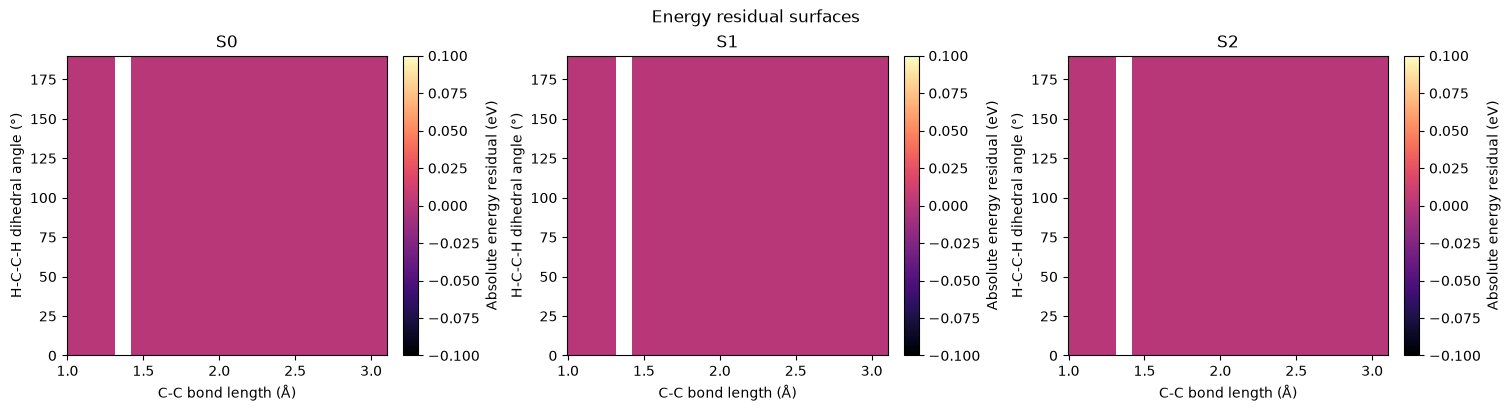

In [3]:
# If REF_energy is available, plot residuals on a 2D surface
# Residual = PRED_energy - REF_energy

try:
    fig, ax = plot_residual_heatmaps(
        atoms_list,
        x_coordinate,
        y_coordinate,
        absolute=True
    )
    plt.show()
except:
    print("Residual cannot be calculated because file contains no REF_energy")

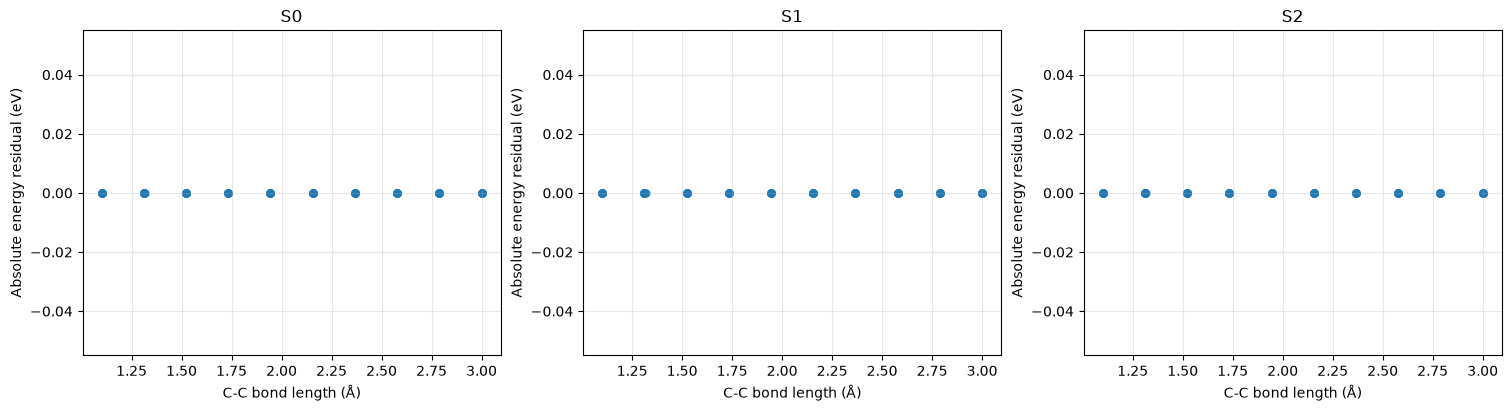

In [4]:
# Plot residual vs one geometry coordinate

# Options: BondLengthCoordinate((a,b)), BondAngleCoordinate((a,b,c)), DihedralCoordinate((a,b,c,d))
coordinate = BondLengthCoordinate((1, 2))

try:
    fig, ax = plot_residual_vs_coordinate(
        atoms_list,
        coordinate,
        absolute=True
    )
    plt.show()
except:
    print("Residual cannot be calculated because file contains no REF_energy")

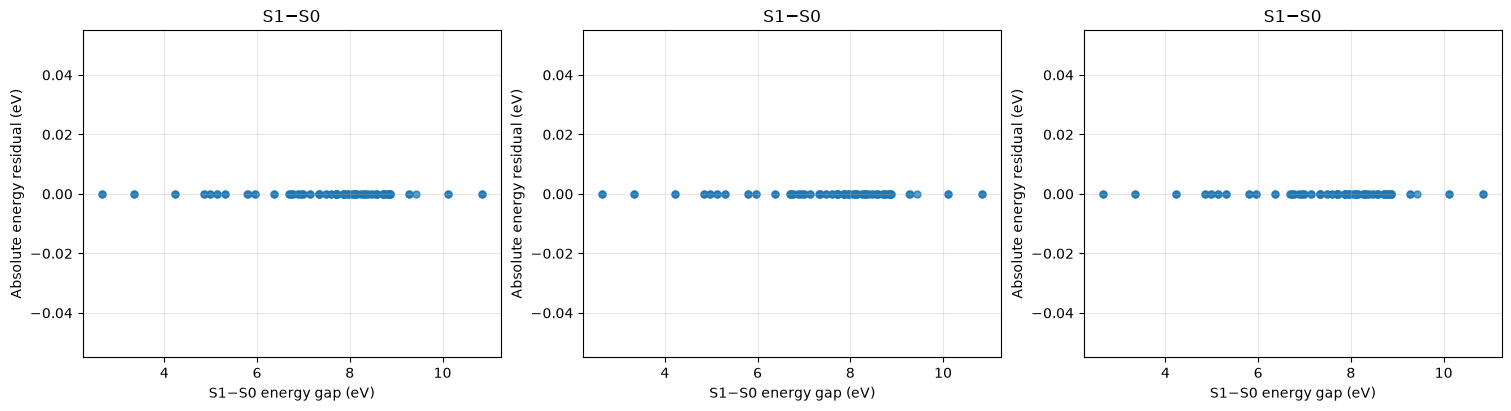

In [5]:
# Plot residual vs energy gap

try:
    fig, ax = plot_residual_vs_gap(
        atoms_list,
        gap_states=(0, 1),
    )
    plt.show()
except:
    print("Residual cannot be calculated because file contains no REF_energy")